In [ ]:
# using Unitful
# using DimensionfulAngles
using DimensionfulAngles.DefaultSymbols
using CairoMakie

push!(LOAD_PATH, "../src")
using WaveSpectra

In [2]:
Nf = 100
Δf = 0.005Hz
f = (Δf:Δf:Δf*Nf)

Nθ = 18
Δθ = 360° / Nθ
θ = (0:Nθ-1) * Δθ

(0.0:20.0:340.0)°

In [3]:
So_1 = ParametricSpectra.spectrum_jonswap(f, 1.5m, 8s)
So = ParametricSpectra.spectrum_pierson_moskowitz(f, 1.5m, 8s)

,data
0.005 Hz,0.0
0.01 Hz,0.0
0.015 Hz,0.0
0.02 Hz,0.0
0.025 Hz,0.0
⋮,⋮
0.48 Hz,0.00669838
0.485 Hz,0.00636163
0.49 Hz,0.00604496
0.495 Hz,0.00574697


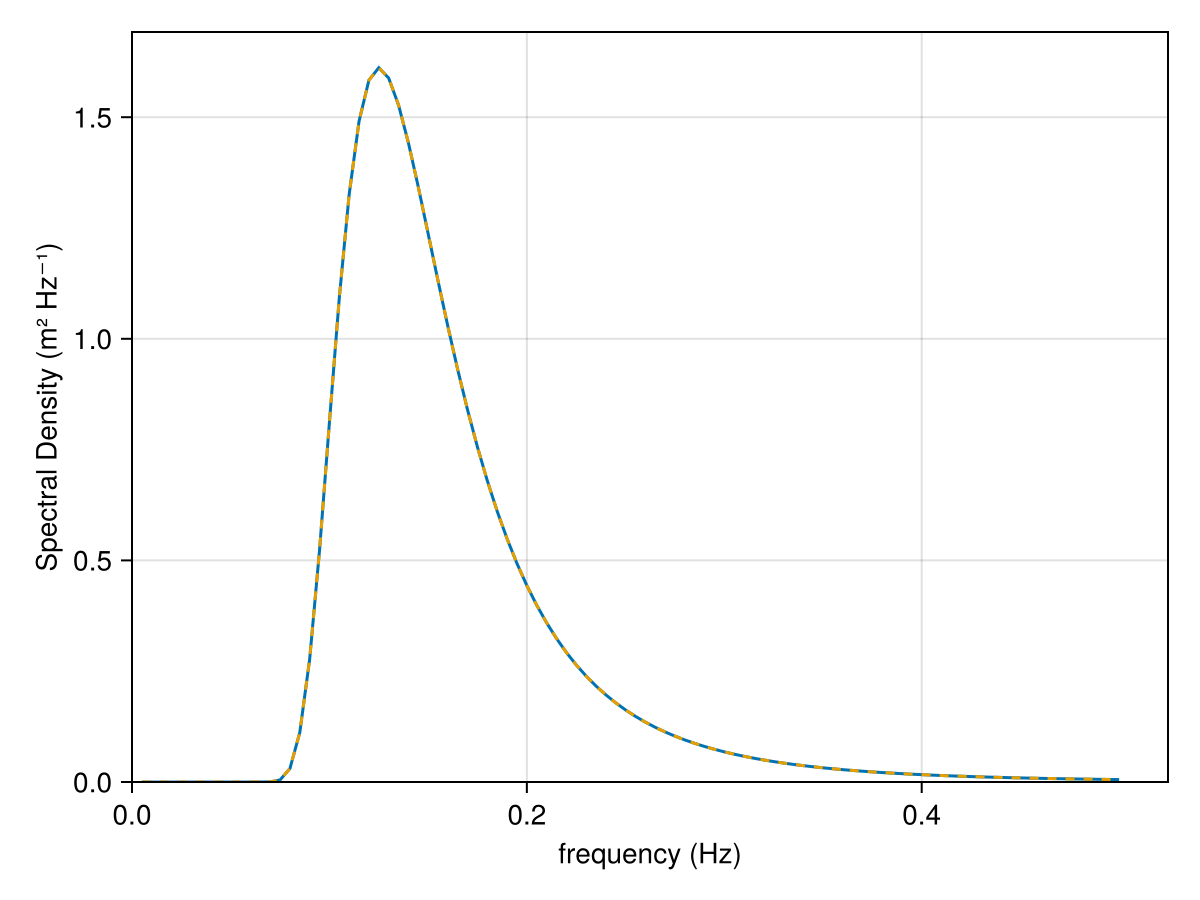

In [4]:
fig = plot_spectrum(So)
plot_spectrum!(current_axis(), So_1; linestyle=:dash)
fig

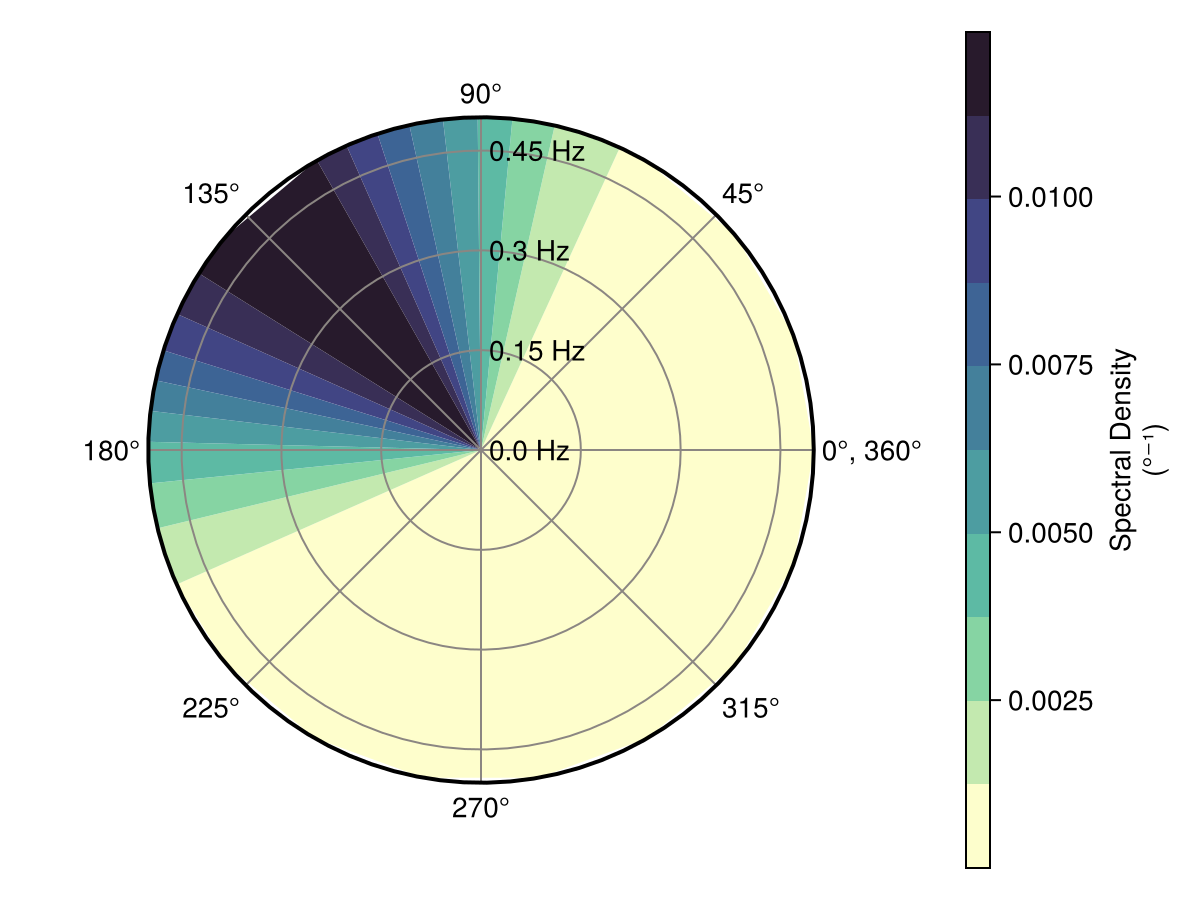

In [5]:
D = ParametricSpectra.spread_cartwright(θ, f, 135°, 30°);
plot_spectrum(D)

In [6]:
S = Spectrum(So, D)

,0.0°,20.0°,40.0°,60.0°,80.0°,100.0°,120.0°,140.0°,160.0°,180.0°,200.0°,220.0°,240.0°,260.0°,280.0°,300.0°,320.0°,340.0°
0.005 Hz,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.01 Hz,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.015 Hz,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.02 Hz,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.025 Hz,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
0.48 Hz,4.72287e-10,3.38624e-8,6.05383e-7,4.5774e-6,1.8654e-5,4.64778e-5,7.57495e-5,8.33974e-5,6.24005e-5,3.11493e-5,9.88663e-6,1.81886e-6,1.63115e-7,5.02507e-9,2.27004e-11,6.20542e-16,6.30354e-22,3.61479e-13
0.485 Hz,4.48544e-10,3.216e-8,5.74948e-7,4.34729e-6,1.77162e-5,4.41412e-5,7.19413e-5,7.92048e-5,5.92634e-5,2.95833e-5,9.3896e-6,1.72742e-6,1.54915e-7,4.77244e-9,2.15592e-11,5.89346e-16,5.98664e-22,3.43306e-13
0.49 Hz,4.26216e-10,3.05591e-8,5.46328e-7,4.13088e-6,1.68343e-5,4.19439e-5,6.83601e-5,7.5262e-5,5.63133e-5,2.81107e-5,8.92219e-6,1.64143e-6,1.47203e-7,4.53487e-9,2.0486e-11,5.60009e-16,5.68863e-22,3.26216e-13
0.495 Hz,4.05206e-10,2.90527e-8,5.19397e-7,3.92725e-6,1.60044e-5,3.98763e-5,6.49904e-5,7.1552e-5,5.35374e-5,2.6725e-5,8.48238e-6,1.56052e-6,1.39947e-7,4.31133e-9,1.94762e-11,5.32403e-16,5.40821e-22,3.10136e-13


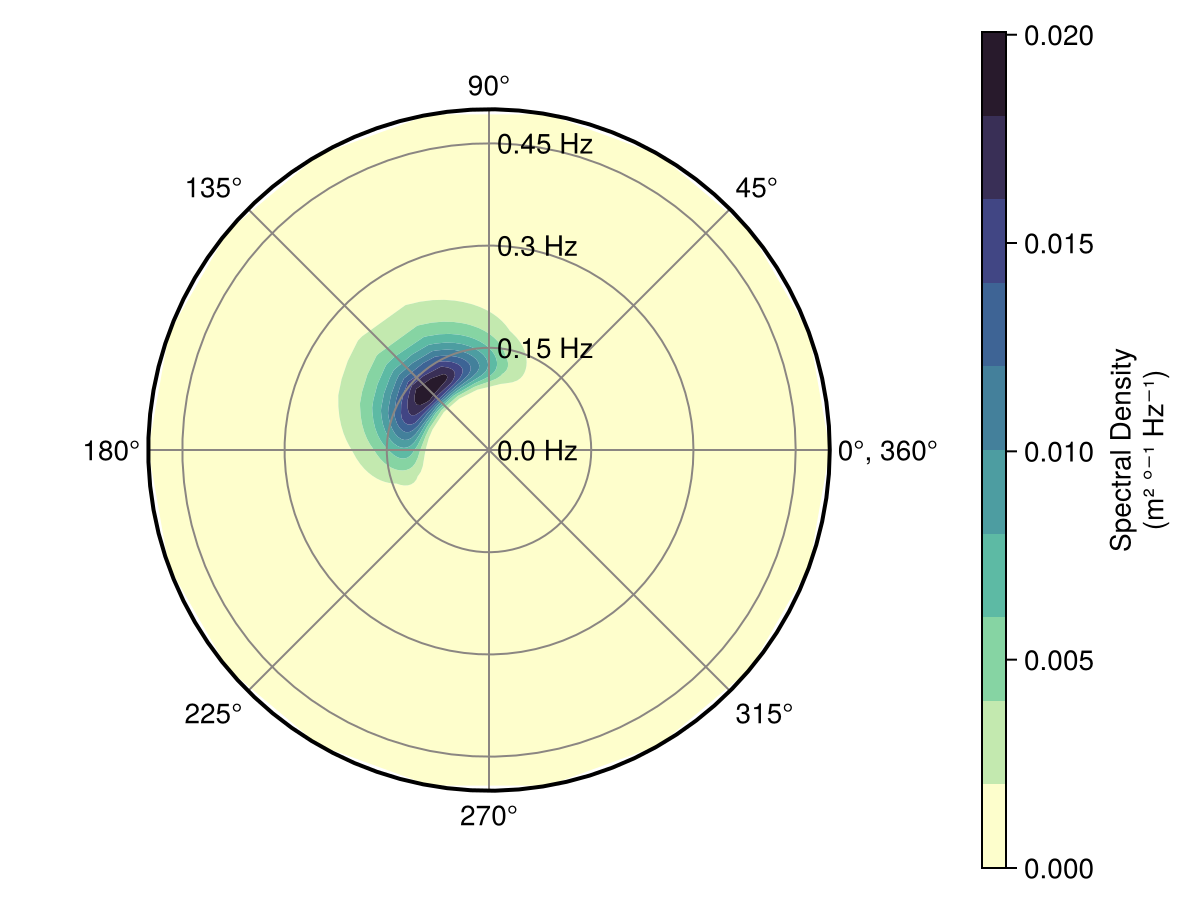

In [7]:
plot_spectrum(S)

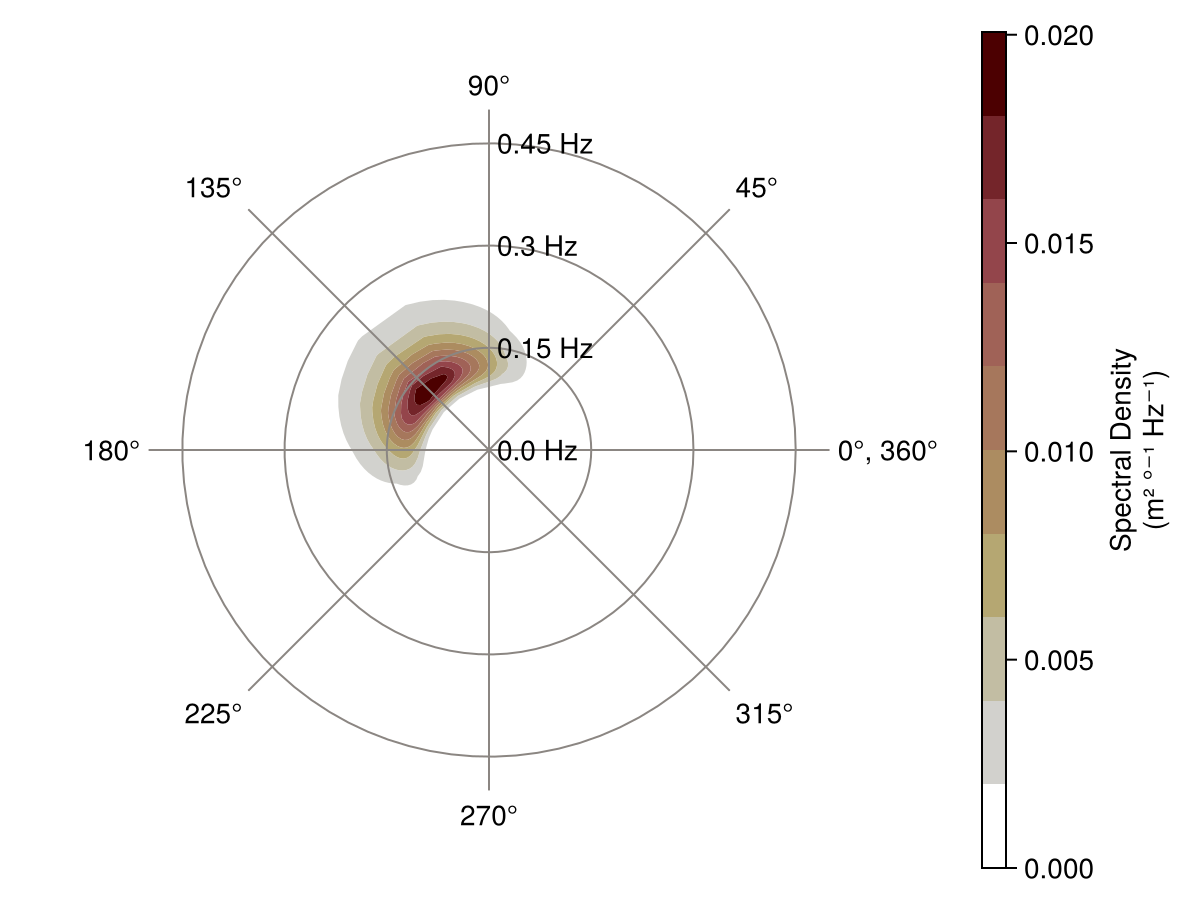

In [8]:
plot_spectrum(S; colormap=cgrad(:bilbao, rev=true), ax_properties=Dict(:spinevisible => false,))
# plot_spectrum(S; (func!)=(contour!), ax_properties=Dict(:spinevisible => false))

In [ ]:
Nf = 10
Δf = 0.1Hz
f = (Δf:Δf:Δf*Nf)

Nθ = 18
Δθ = 360° / Nθ
θ = (0:Nθ-1) * Δθ

S = Spectrum(abs.(randn(Nf, Nθ) .+ 0.01) * m^2 / Hz / °, f, θ);

In [ ]:
S2 = uconvert(rad/m, :axis1, S, DispersionRelations.deepwater_gravitywaves());
S3 = uconvert(rad / m, :axis1, S, DispersionRelations.gravitywaves(1000m));

In [ ]:
integrate(S), integrate(S2), integrate(S3)

In [ ]:
uconvert(rad/s, 20s, Dispersion())

In [ ]:
So =